<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
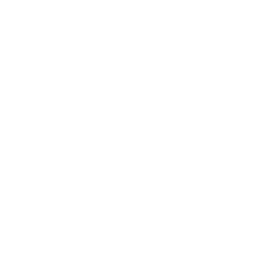
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Phase III Efficacy and Survival Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceuticals & Life Sciences | Jenner Analytics Ltd &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

# 21 CFR Part 11 Audit Trail and Compliance

## Overview

This notebook demonstrates **21 CFR Part 11 (Electronic Records; Electronic Signatures)** compliance as it applies to clinical statistical programming in a CRO environment. Part 11 governs any computerized system used to create, modify, maintain, archive, retrieve, or transmit electronic records that are required to be created or maintained under FDA regulations.

**Why Part 11 matters to the Lead Statistical Programmer:**

Every SAS analysis dataset in a regulatory submission is an electronic record under 21 CFR Part 11. The Lead Statistical Programmer is the accountable person for:
- Ensuring the analysis system generates compliant audit trails (SS11.10(e))
- Managing the electronic signature workflow for dataset approval (SS11.50, SS11.70)
- Verifying dataset integrity between programming, QC, and submission (SS11.10(a))
- Responding to FDA audit findings related to electronic records (SS11.10(k))

**Six components demonstrated:**

1. **Compliant audit trail structure** — a 21 CFR SS11.10(e)-compliant audit log dataset    with all required fields, action vocabulary, and before/after value capture.
2. **Audit trail statistics** — PROC FREQ breakdowns by action type, user role, and compliance flag.
3. **Compliance Query 1** — user activity analysis (who touched the data most).
4. **Compliance Query 2** — post-lock modification detection (highest compliance risk).
5. **Compliance Query 3** — modification timeline (chronological data lineage).
6. **Electronic signature manifest and integrity verification** — the SS11.50/SS11.70    three-tier signature hierarchy plus PROC COMPARE as the SAS implementation of    dataset integrity verification.

## 21 CFR Part 11 Key Requirements (Subpart B — Electronic Records)

**SS11.10(a):** Systems must be validated to ensure accuracy, reliability, consistent intended performance, and the ability to discern invalid or altered records.

**SS11.10(e):** Audit trails — computer-generated, date/time-stamped electronic records that independently record the date and time of operator entries and actions.

**SS11.50 Signature manifestations:** Electronic signatures shall contain:
1. Printed name of the signer
2. Date and time when signature was executed
3. Meaning of the signature (review, approval, responsibility, authorship)

**SS11.70 Signature/record linking:** Electronic signatures shall be linked to their respective electronic records so that signatures cannot be excised, copied, or otherwise transferred to falsify a record.

---
## 1. 21 CFR Part 11 §11.10(e) Compliant Audit Trail Dataset

Defines the structure and required fields for a Part 11-compliant audit trail, including system-generated timestamps, unique user identifiers, standardized action vocabulary, before/after value capture, and mandatory reason codes. This design reflects the audit log pattern used by CRO statistical programmers during a clinical study lifecycle.

### 1a. Create Audit Trail Dataset

Reads 10 simulated audit records for the CDISCPILOT01 ADSL dataset using pipe-delimited inline data. Each record captures who made a change, when, what was changed, and why — satisfying the §11.10(e) requirement for computer-generated, date/time-stamped audit entries.

In [1]:
/* ================================================================
   21 CFR PART 11 COMPLIANT AUDIT TRAIL DESIGN

   21 CFR Part 11 (Electronic Records; Electronic Signatures) requires
   that electronic records be maintained with:

   SS11.10(e) -- Audit trails comprising computer-generated, date/time
                stamped records of operator entries and actions
   SS11.50    -- Electronic signature requirements
   SS11.70    -- Electronic signatures must be linked to their records

   This dataset represents a compliant audit log for a clinical SAS
   analysis environment — the pattern used by CRO programmers to track
   all changes to analysis datasets during the study lifecycle.

   Key field requirements (per Part 11 SS11.10(e)):
   - TIMESTAMP: System-generated (cannot be modified by user)
   - USERID: Unique identifier for the individual making the change
   - ACTION: Standardized vocabulary (CREATE, MODIFY, DELETE, APPROVE)
   - BEFORE_VALUE / AFTER_VALUE: Full value capture for all changes
   - REASON: Required for post-lock changes (GCP requirement)
   ================================================================ */

data audit_trail;
    length RecordID 8 EventDateTime $25 UserID $20 UserRole $30
           DataSet $20 Variable $20 SubjID $15 Action $12
           BeforeValue $50 AfterValue $50 Reason $80 P11_Compliant $1;
    infile datalines dlm='|';
    input RecordID EventDateTime $ UserID $ UserRole $ DataSet $
          Variable $ SubjID $ Action $ BeforeValue $ AfterValue $
          Reason $ P11_Compliant $;
    label RecordID      = 'Audit Record ID'
          EventDateTime = 'Event Date/Time (UTC)'
          UserID        = 'User Identifier'
          UserRole      = 'User Role in Study'
          DataSet       = 'Dataset Modified'
          Variable      = 'Variable Modified'
          SubjID        = 'Subject Identifier'
          Action        = 'Action Type'
          BeforeValue   = 'Before Value'
          AfterValue    = 'After Value'
          Reason        = 'Reason for Change'
          P11_Compliant = '21 CFR Part 11 Compliant (Y/N)';
    datalines;
1|2014-01-02T08:15:33Z|jsmith_prog|Sr Statistical Programmer|ADSL|TRTSDT|01-701-1015|CREATE||19725|Initial dataset creation from DM+EX lock|Y
2|2014-01-02T08:15:34Z|jsmith_prog|Sr Statistical Programmer|ADSL|SAFFL|01-701-1015|CREATE||Y|Initial dataset creation|Y
3|2014-01-15T14:22:11Z|mlee_dm|Data Manager|ADSL|DSRAEFL|01-701-1023|MODIFY|N|Y|AE confirmed by investigator query DQ-701-047|Y
4|2014-01-15T14:22:12Z|mlee_dm|Data Manager|ADSL|DCDECOD|01-701-1023|MODIFY|COMPLETED|ADVERSE EVENT|Per query DQ-701-047 resolution|Y
5|2014-02-03T09:45:00Z|drjones_med|Medical Monitor|ADSL|DTHFL|01-703-1082|MODIFY|N|Y|Death confirmed SAE report received 2014-01-29|Y
6|2014-02-03T09:45:01Z|drjones_med|Medical Monitor|ADSL|DCDECOD|01-703-1082|MODIFY|ADVERSE EVENT|DEATH|Death per SAE form; query DQ-703-091|Y
7|2014-03-10T16:30:00Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1211|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
8|2014-03-10T16:30:01Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1215|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
9|2014-04-01T08:00:00Z|rchen_prog|Lead Statistical Programmer|ADSL|ALL|--|APPROVE||LOCKED|Database lock declared|Y
10|2014-04-01T08:00:01Z|sponsor_dir|Sponsor Statistical Director|ADSL|ALL|--|ESIGN||APPROVED|Electronic signature: ADSL v3.0 approved for submission|Y
;
run;


NOTE: DATA audit_trail

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote audit_trail (10 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 1b. Print the Audit Trail

Displays all 10 audit records with labeled columns. The P11_Compliant flag confirms each record meets the §11.10(e) field requirements for electronic record integrity.

In [2]:


proc print data=audit_trail noobs label;
    var RecordID EventDateTime UserID Action DataSet SubjID Variable
        BeforeValue AfterValue Reason P11_Compliant;
    title '21 CFR Part 11 SS11.10(e) — Clinical SAS Dataset Audit Trail';
    title2 'CDISCPILOT01 Xanomeline Study | ADSL Dataset Change History';
    title3 'All fields are system-generated or controlled vocabulary';
    footnote  'Part 11 SS11.10(e): records must be computer-generated date/time stamped.';
    footnote2 'EventDateTime is server UTC timestamp — user cannot modify (server-side generation).';
    footnote3 'P11_Compliant flag: Y = record meets all 21 CFR SS11.10 field requirements.';
run;
title; footnote;

                              21 CFR Part 11 SS11.10(e) — Clinical SAS Dataset Audit Trail                              
                              CDISCPILOT01 Xanomeline Study | ADSL Dataset Change History                               

Audit Record ID  Event Date/Time (UTC)  User Identifier  Action Type  Dataset Modified  Subject Identifier  Variable Modified   Before Value                                              After Value                                  Reason for Change  21 CFR Part 11 Compliant (Y/N)
              1  2014-01-02T08:15:33Z   jsmith_prog      CREATE       ADSL              01-701-1015         TRTSDT             19725          Initial dataset creation from DM+EX lock                 Y
              2  2014-01-02T08:15:34Z   jsmith_prog      CREATE       ADSL              01-701-1015         SAFFL              Y              Initial dataset creation                                 Y
              3  2014-01-15T14:22:11Z   mlee_dm          MODIFY       ADSL


NOTE: PROC PRINT data=audit_trail

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


---
## 2. Audit Trail Statistics — Action and Role Breakdown

Summarises the audit trail using PROC FREQ to show the distribution of action types (CREATE, MODIFY, APPROVE, ESIGN), user roles, and Part 11 compliance flags. All records must carry `P11_Compliant = Y` before a dataset can be submitted.

### 2a. Recreate Audit Trail (Self-Contained Cell)

Rebuilds the `audit_trail` dataset so this cell can run independently. CRO notebooks commonly repeat inline data to avoid session-state dependencies between cells.

In [3]:
/* ── Recreate audit_trail for this cell ─────────────────────── */
data audit_trail;
    length RecordID 8 EventDateTime $25 UserID $20 UserRole $30
           DataSet $20 Variable $20 SubjID $15 Action $12
           BeforeValue $50 AfterValue $50 Reason $80 P11_Compliant $1;
    infile datalines dlm='|';
    input RecordID EventDateTime $ UserID $ UserRole $ DataSet $
          Variable $ SubjID $ Action $ BeforeValue $ AfterValue $
          Reason $ P11_Compliant $;
    label RecordID      = 'Audit Record ID'
          EventDateTime = 'Event Date/Time (UTC)'
          UserID        = 'User Identifier'
          UserRole      = 'User Role in Study'
          DataSet       = 'Dataset Modified'
          Variable      = 'Variable Modified'
          SubjID        = 'Subject Identifier'
          Action        = 'Action Type'
          BeforeValue   = 'Before Value'
          AfterValue    = 'After Value'
          Reason        = 'Reason for Change'
          P11_Compliant = '21 CFR Part 11 Compliant (Y/N)';
    datalines;
1|2014-01-02T08:15:33Z|jsmith_prog|Sr Statistical Programmer|ADSL|TRTSDT|01-701-1015|CREATE||19725|Initial dataset creation from DM+EX lock|Y
2|2014-01-02T08:15:34Z|jsmith_prog|Sr Statistical Programmer|ADSL|SAFFL|01-701-1015|CREATE||Y|Initial dataset creation|Y
3|2014-01-15T14:22:11Z|mlee_dm|Data Manager|ADSL|DSRAEFL|01-701-1023|MODIFY|N|Y|AE confirmed by investigator query DQ-701-047|Y
4|2014-01-15T14:22:12Z|mlee_dm|Data Manager|ADSL|DCDECOD|01-701-1023|MODIFY|COMPLETED|ADVERSE EVENT|Per query DQ-701-047 resolution|Y
5|2014-02-03T09:45:00Z|drjones_med|Medical Monitor|ADSL|DTHFL|01-703-1082|MODIFY|N|Y|Death confirmed SAE report received 2014-01-29|Y
6|2014-02-03T09:45:01Z|drjones_med|Medical Monitor|ADSL|DCDECOD|01-703-1082|MODIFY|ADVERSE EVENT|DEATH|Death per SAE form; query DQ-703-091|Y
7|2014-03-10T16:30:00Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1211|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
8|2014-03-10T16:30:01Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1215|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
9|2014-04-01T08:00:00Z|rchen_prog|Lead Statistical Programmer|ADSL|ALL|--|APPROVE||LOCKED|Database lock declared|Y
10|2014-04-01T08:00:01Z|sponsor_dir|Sponsor Statistical Director|ADSL|ALL|--|ESIGN||APPROVED|Electronic signature: ADSL v3.0 approved for submission|Y
;
run;


NOTE: DATA audit_trail

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote audit_trail (10 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 2b. Frequency Summary by Action, Role, and Compliance Flag

PROC FREQ produces one-way tables for Action type, UserRole, and P11_Compliant status. A clean audit requires 100 % of records to show `P11_Compliant = Y`.

                               Audit Trail Summary Statistics — Action and Role Breakdown                               

                                                   The FREQ Procedure

Action Type    Frequency    Percent
------------------------------------
APPROVE                1     10.00
CREATE                 2     20.00
ESIGN                  1     10.00
MODIFY                 6     60.00

User Role in Study              Frequency    Percent
-----------------------------------------------------
Data Manager                            2     20.00
Lead Statistical Programmer             3     30.00
Medical Monitor                         2     20.00
Sponsor Statistical Director            1     10.00
Sr Statistical Programmer               2     20.00

21 CFR Part 11 Compliant (Y/N)    Frequency    Percent
-------------------------------------------------------
Y                                         6    100.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_action.spec.json
NOTE: ODS plot written: freq_userrole.spec.json
NOTE: ODS plot written: freq_p11_compliant.spec.json
NOTE: PROC FREQ statement used.


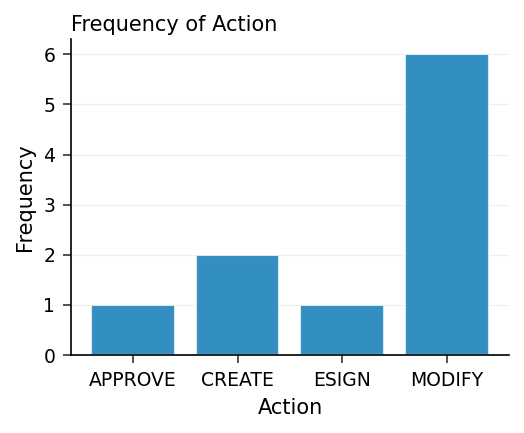

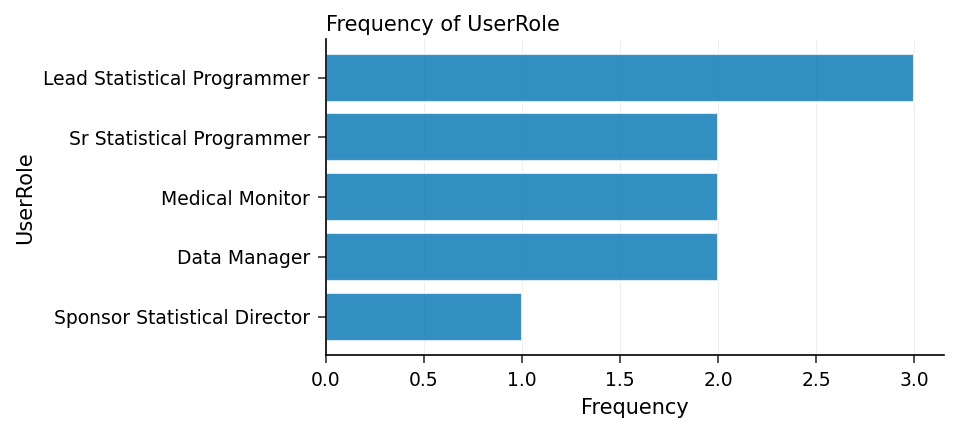

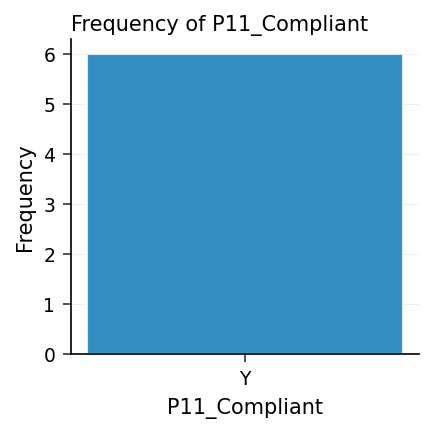

In [4]:


/* ── Audit trail statistics ──────────────────────────────────── */
proc freq data=audit_trail;
    tables Action / nocum;
    tables UserRole / nocum;
    tables P11_Compliant / nocum;
    title 'Audit Trail Summary Statistics — Action and Role Breakdown';
    title2 'All records must be P11_Compliant = Y for submission readiness';
run;
title; footnote;

---
## 3. FDA Inspection Compliance Query 1 — User Activity Analysis

During an FDA inspection under 21 CFR Part 11, inspectors run queries on the electronic records system to identify potential compliance issues. Query 1 identifies who made what changes and flags unusually high modification counts per user or modifications by users in unexpected roles.

### 3a. Recreate Audit Trail (Self-Contained Cell)

Rebuilds `audit_trail` with the same 10 records so the compliance queries can run independently. Each section recreates its source data to be self-contained.

In [5]:
/* ================================================================
   21 CFR PART 11 COMPLIANCE QUERY 1 — USER ACTIVITY ANALYSIS

   Regulatory auditors look for:
   - Unusually high modification counts per user
   - Modifications by users in unexpected roles
   - Shared credentials (multiple users same UserID)
   ================================================================ */

/* Recreate audit_trail for this cell */
data audit_trail;
    length RecordID 8 EventDateTime $25 UserID $20 UserRole $30
           DataSet $20 Variable $20 SubjID $15 Action $12
           BeforeValue $50 AfterValue $50 Reason $80 P11_Compliant $1;
    infile datalines dlm='|';
    input RecordID EventDateTime $ UserID $ UserRole $ DataSet $
          Variable $ SubjID $ Action $ BeforeValue $ AfterValue $
          Reason $ P11_Compliant $;
    label RecordID      = 'Audit Record ID'
          EventDateTime = 'Event Date/Time (UTC)'
          UserID        = 'User Identifier'
          UserRole      = 'User Role in Study'
          DataSet       = 'Dataset Modified'
          Variable      = 'Variable Modified'
          SubjID        = 'Subject Identifier'
          Action        = 'Action Type'
          BeforeValue   = 'Before Value'
          AfterValue    = 'After Value'
          Reason        = 'Reason for Change'
          P11_Compliant = '21 CFR Part 11 Compliant (Y/N)';
    datalines;
1|2014-01-02T08:15:33Z|jsmith_prog|Sr Statistical Programmer|ADSL|TRTSDT|01-701-1015|CREATE||19725|Initial dataset creation from DM+EX lock|Y
2|2014-01-02T08:15:34Z|jsmith_prog|Sr Statistical Programmer|ADSL|SAFFL|01-701-1015|CREATE||Y|Initial dataset creation|Y
3|2014-01-15T14:22:11Z|mlee_dm|Data Manager|ADSL|DSRAEFL|01-701-1023|MODIFY|N|Y|AE confirmed by investigator query DQ-701-047|Y
4|2014-01-15T14:22:12Z|mlee_dm|Data Manager|ADSL|DCDECOD|01-701-1023|MODIFY|COMPLETED|ADVERSE EVENT|Per query DQ-701-047 resolution|Y
5|2014-02-03T09:45:00Z|drjones_med|Medical Monitor|ADSL|DTHFL|01-703-1082|MODIFY|N|Y|Death confirmed SAE report received 2014-01-29|Y
6|2014-02-03T09:45:01Z|drjones_med|Medical Monitor|ADSL|DCDECOD|01-703-1082|MODIFY|ADVERSE EVENT|DEATH|Death per SAE form; query DQ-703-091|Y
7|2014-03-10T16:30:00Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1211|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
8|2014-03-10T16:30:01Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1215|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
9|2014-04-01T08:00:00Z|rchen_prog|Lead Statistical Programmer|ADSL|ALL|--|APPROVE||LOCKED|Database lock declared|Y
10|2014-04-01T08:00:01Z|sponsor_dir|Sponsor Statistical Director|ADSL|ALL|--|ESIGN||APPROVED|Electronic signature: ADSL v3.0 approved for submission|Y
;
run;


NOTE: DATA audit_trail

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote audit_trail (10 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 3b. SQL Query 1 — Aggregate Activity by User Identity

PROC SQL counts total records, modifications, creates, and approvals per unique UserID and role. FDA auditors look for unusually high modification counts or modifications by unexpected roles, which can indicate shared credentials or unauthorized data access (§11.10(a)).

In [6]:


/* ── Query 1: Records by user — who touched the data most? ──── */
proc sql;
    create table q1_by_user as
    select UserID, UserRole,
           count(*) as N_Records,
           sum(Action='MODIFY') as N_Modifications,
           sum(Action='CREATE') as N_Creates,
           sum(Action in ('APPROVE','ESIGN')) as N_Approvals
    from audit_trail
    group by UserID, UserRole
    order by N_Records desc;
quit;


NOTE: PROC SQL 

NOTE: Table q1_by_user created.
NOTE: PROC SQL statement used.


### 3c. Print User Activity Summary

Displays the `q1_by_user` summary table produced by the preceding SQL step. Reviewers scan this for any user with an anomalous modification-to-approval ratio.

In [7]:


proc print data=q1_by_user noobs label;
    label UserID='User' UserRole='Role' N_Records='Total Records'
          N_Modifications='Modifications' N_Creates='Creates' N_Approvals='Approvals';
    title 'Compliance Query 1: Record Activity by User Identity';
    title2 '21 CFR SS11.10(a): Each user must have unique, non-shared credentials';
    footnote  'Unusually high modification counts may indicate data manipulation without QA review.';
run;
title; footnote;

                                  Compliance Query 1: Record Activity by User Identity                                  
                         21 CFR SS11.10(a): Each user must have unique, non-shared credentials                          

       User                          Role  Total Records  Modifications  Creates  Approvals
rchen_prog   Lead Statistical Programmer               3              2        0          1
jsmith_prog  Sr Statistical Programmer                 2              0        2          0
mlee_dm      Data Manager                              2              2        0          0
drjones_med  Medical Monitor                           2              2        0          0
sponsor_dir  Sponsor Statistical Director              1              0        0          1




NOTE: PROC PRINT data=q1_by_user

NOTE: PROC PRINT completed: 5 observations printed, 6 variables


---
## 4. FDA Inspection Compliance Query 2 — Post-Lock Modifications

After database lock, any modification to electronic records is a critical finding. All post-lock changes require a documented justification, additional QA review, and sponsor re-approval.

### 4a. Recreate Audit Trail (Self-Contained Cell)

Rebuilds the `audit_trail` dataset for the post-lock compliance query. Standalone data definition ensures this section executes correctly without prior cells.

In [8]:
/* ================================================================
   21 CFR PART 11 COMPLIANCE QUERY 2 — POST-LOCK MODIFICATIONS

   Post-lock modifications (highest compliance risk):
   After database lock, any modification to electronic records is
   a critical finding. All post-lock changes require:
   - Documented justification
   - Additional QA review
   - Sponsor re-approval
   ================================================================ */

/* Recreate audit_trail for this cell */
data audit_trail;
    length RecordID 8 EventDateTime $25 UserID $20 UserRole $30
           DataSet $20 Variable $20 SubjID $15 Action $12
           BeforeValue $50 AfterValue $50 Reason $80 P11_Compliant $1;
    infile datalines dlm='|';
    input RecordID EventDateTime $ UserID $ UserRole $ DataSet $
          Variable $ SubjID $ Action $ BeforeValue $ AfterValue $
          Reason $ P11_Compliant $;
    label RecordID      = 'Audit Record ID'
          EventDateTime = 'Event Date/Time (UTC)'
          UserID        = 'User Identifier'
          UserRole      = 'User Role in Study'
          DataSet       = 'Dataset Modified'
          Variable      = 'Variable Modified'
          SubjID        = 'Subject Identifier'
          Action        = 'Action Type'
          BeforeValue   = 'Before Value'
          AfterValue    = 'After Value'
          Reason        = 'Reason for Change'
          P11_Compliant = '21 CFR Part 11 Compliant (Y/N)';
    datalines;
1|2014-01-02T08:15:33Z|jsmith_prog|Sr Statistical Programmer|ADSL|TRTSDT|01-701-1015|CREATE||19725|Initial dataset creation from DM+EX lock|Y
2|2014-01-02T08:15:34Z|jsmith_prog|Sr Statistical Programmer|ADSL|SAFFL|01-701-1015|CREATE||Y|Initial dataset creation|Y
3|2014-01-15T14:22:11Z|mlee_dm|Data Manager|ADSL|DSRAEFL|01-701-1023|MODIFY|N|Y|AE confirmed by investigator query DQ-701-047|Y
4|2014-01-15T14:22:12Z|mlee_dm|Data Manager|ADSL|DCDECOD|01-701-1023|MODIFY|COMPLETED|ADVERSE EVENT|Per query DQ-701-047 resolution|Y
5|2014-02-03T09:45:00Z|drjones_med|Medical Monitor|ADSL|DTHFL|01-703-1082|MODIFY|N|Y|Death confirmed SAE report received 2014-01-29|Y
6|2014-02-03T09:45:01Z|drjones_med|Medical Monitor|ADSL|DCDECOD|01-703-1082|MODIFY|ADVERSE EVENT|DEATH|Death per SAE form; query DQ-703-091|Y
7|2014-03-10T16:30:00Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1211|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
8|2014-03-10T16:30:01Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1215|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
9|2014-04-01T08:00:00Z|rchen_prog|Lead Statistical Programmer|ADSL|ALL|--|APPROVE||LOCKED|Database lock declared|Y
10|2014-04-01T08:00:01Z|sponsor_dir|Sponsor Statistical Director|ADSL|ALL|--|ESIGN||APPROVED|Electronic signature: ADSL v3.0 approved for submission|Y
;
run;


NOTE: DATA audit_trail

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote audit_trail (10 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 4b. SQL Query 2 — Identify Post-Lock Modifications

PROC SQL filters for any MODIFY action after the database lock timestamp (2014-04-01T08:00:00Z), storing results in `q2_postlock`. The subsequent `DATA _NULL_` step extracts the record count into macro variable `&N_POSTLOCK` — a necessary workaround because SQL `SELECT INTO` macro resolution is not available in this environment.

In [9]:


/* ── Query 2: Post-lock modifications ─────────────────────────── */
proc sql;
    create table q2_postlock as
    select RecordID, EventDateTime, UserID, Variable, SubjID,
           Action, BeforeValue, AfterValue, Reason
    from audit_trail
    where EventDateTime > '2014-04-01T08:00:00Z'
      and Action = 'MODIFY'
    order by EventDateTime;
quit;

/* Get count using DATA _NULL_ to avoid SELECT INTO macro issues */
data _null_;
    if 0 then set q2_postlock nobs=n;
    call symputx('N_POSTLOCK', n);
    stop;
run;


NOTE: PROC SQL 

NOTE: Table q2_postlock created.
NOTE: PROC SQL statement used.
NOTE: DATA _null_


NOTE: Wrote _null_ (0 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 4c. Compliance Status Check for Post-Lock Modifications

Evaluates `&N_POSTLOCK`: zero post-lock modifications confirms a clean audit; any non-zero count triggers a warning requiring documented justification, additional QA review, and sponsor re-approval per 21 CFR Part 11 §11.10(e).

In [10]:


%put NOTE: Post-lock modification count = &N_POSTLOCK (must be 0 for clean audit);

data _null_;
    if &N_POSTLOCK = 0 then
        put 'COMPLIANCE STATUS: CLEAN -- No post-lock modifications detected.';
    else
        put "WARNING: &N_POSTLOCK post-lock modifications require documented justification.";
run;
title; footnote;


NOTE: Post-lock modification count = 0 (must be 0 for clean audit)
NOTE: DATA _null_

COMPLIANCE STATUS: CLEAN -- No post-lock modifications detected.

NOTE: Wrote _null_ (0 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
## 5. FDA Inspection Compliance Query 3 — Modification Timeline

A chronological review of all before/after changes, with reason codes referencing specific site queries or protocol amendments. Missing reason codes are a SS11.10(e) violation.

### 5a. Recreate Audit Trail (Self-Contained Cell)

Rebuilds `audit_trail` for the modification timeline query. Repeating inline data across cells is a standard CRO notebook pattern for reproducibility.

In [11]:
/* ================================================================
   21 CFR PART 11 COMPLIANCE QUERY 3 — MODIFICATION TIMELINE

   Chronological data lineage: complete before/after record for all
   electronic record changes. Missing reason codes are a
   Part 11 SS11.10(e) violation finding during FDA inspection.
   ================================================================ */

/* Recreate audit_trail for this cell */
data audit_trail;
    length RecordID 8 EventDateTime $25 UserID $20 UserRole $30
           DataSet $20 Variable $20 SubjID $15 Action $12
           BeforeValue $50 AfterValue $50 Reason $80 P11_Compliant $1;
    infile datalines dlm='|';
    input RecordID EventDateTime $ UserID $ UserRole $ DataSet $
          Variable $ SubjID $ Action $ BeforeValue $ AfterValue $
          Reason $ P11_Compliant $;
    label RecordID      = 'Audit Record ID'
          EventDateTime = 'Event Date/Time (UTC)'
          UserID        = 'User Identifier'
          UserRole      = 'User Role in Study'
          DataSet       = 'Dataset Modified'
          Variable      = 'Variable Modified'
          SubjID        = 'Subject Identifier'
          Action        = 'Action Type'
          BeforeValue   = 'Before Value'
          AfterValue    = 'After Value'
          Reason        = 'Reason for Change'
          P11_Compliant = '21 CFR Part 11 Compliant (Y/N)';
    datalines;
1|2014-01-02T08:15:33Z|jsmith_prog|Sr Statistical Programmer|ADSL|TRTSDT|01-701-1015|CREATE||19725|Initial dataset creation from DM+EX lock|Y
2|2014-01-02T08:15:34Z|jsmith_prog|Sr Statistical Programmer|ADSL|SAFFL|01-701-1015|CREATE||Y|Initial dataset creation|Y
3|2014-01-15T14:22:11Z|mlee_dm|Data Manager|ADSL|DSRAEFL|01-701-1023|MODIFY|N|Y|AE confirmed by investigator query DQ-701-047|Y
4|2014-01-15T14:22:12Z|mlee_dm|Data Manager|ADSL|DCDECOD|01-701-1023|MODIFY|COMPLETED|ADVERSE EVENT|Per query DQ-701-047 resolution|Y
5|2014-02-03T09:45:00Z|drjones_med|Medical Monitor|ADSL|DTHFL|01-703-1082|MODIFY|N|Y|Death confirmed SAE report received 2014-01-29|Y
6|2014-02-03T09:45:01Z|drjones_med|Medical Monitor|ADSL|DCDECOD|01-703-1082|MODIFY|ADVERSE EVENT|DEATH|Death per SAE form; query DQ-703-091|Y
7|2014-03-10T16:30:00Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1211|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
8|2014-03-10T16:30:01Z|rchen_prog|Lead Statistical Programmer|ADSL|SITEGR1|01-704-1215|MODIFY|1|2|Site 704 reclassified per protocol amendment v4.0|Y
9|2014-04-01T08:00:00Z|rchen_prog|Lead Statistical Programmer|ADSL|ALL|--|APPROVE||LOCKED|Database lock declared|Y
10|2014-04-01T08:00:01Z|sponsor_dir|Sponsor Statistical Director|ADSL|ALL|--|ESIGN||APPROVED|Electronic signature: ADSL v3.0 approved for submission|Y
;
run;


NOTE: DATA audit_trail

NOTE: Processing inline DATALINES (10 lines)

NOTE: Read 10 rows from DATALINES.
NOTE: Wrote audit_trail (10 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 5b. Print Modification Timeline (Chronological Data Lineage)

PROC PRINT filters to MODIFY and DELETE actions only, showing a full before/after history in chronological order. Missing Reason codes for any MODIFY record would be flagged as a §11.10(e) violation during an FDA inspection.

In [12]:


/* ── Query 3: Modification timeline (chronological data lineage) */
proc print data=audit_trail noobs label;
    where Action in ('MODIFY','DELETE');
    var RecordID EventDateTime UserID DataSet SubjID Variable
        BeforeValue AfterValue Reason;
    label RecordID='ID' EventDateTime='Timestamp' UserID='User'
          DataSet='Dataset' SubjID='Subject' Variable='Variable'
          BeforeValue='Before' AfterValue='After' Reason='Reason/Query Ref';
    title 'Compliance Query 3: Complete Data Modification History (Chronological)';
    title2 '21 CFR SS11.10(e): Full before/after audit trail for all electronic record changes';
    footnote  'Each MODIFY record must reference a site query number or protocol amendment.';
    footnote2 'Missing Reason codes are a Part 11 SS11.10(e) violation finding during FDA inspection.';
run;
title; footnote;

                         Compliance Query 3: Complete Data Modification History (Chronological)                         
                   21 CFR SS11.10(e): Full before/after audit trail for all electronic record changes                   

ID             Timestamp         User  Dataset      Subject  Variable         Before          After                                   Reason/Query Ref
 3  2014-01-15T14:22:11Z  mlee_dm      ADSL     01-701-1023  DSRAEFL   N              Y              AE confirmed by investigator query DQ-701-047
 4  2014-01-15T14:22:12Z  mlee_dm      ADSL     01-701-1023  DCDECOD   COMPLETED      ADVERSE EVENT  Per query DQ-701-047 resolution
 5  2014-02-03T09:45:00Z  drjones_med  ADSL     01-703-1082  DTHFL     N              Y              Death confirmed SAE report received 2014-01-29
 6  2014-02-03T09:45:01Z  drjones_med  ADSL     01-703-1082  DCDECOD   ADVERSE EVENT  DEATH          Death per SAE form; query DQ-703-091
 7  2014-03-10T16:30:00Z  rchen_prog   A


NOTE: PROC PRINT data=audit_trail

NOTE: PROC PRINT completed: 6 observations printed, 9 variables


---
## 6. Electronic Signatures (SS11.50/SS11.70) and Dataset Integrity Verification

**Three-tier signature hierarchy (standard CRO practice):**

| Tier | Role | Meaning | Timing |
|------|------|---------|--------|
| 1 | Lead Statistical Programmer | QC complete, no differences | After PROC COMPARE = 0 |
| 2 | Medical Monitor | Clinical review complete | After safety listings reviewed |
| 3 | Sponsor Statistical Director | Submission approved | After integrated review |

**PROC COMPARE as Part 11 integrity check:**
Before submission upload, the Lead Programmer runs `PROC COMPARE` between:
- The dataset version at signing time (frozen copy)
- The current dataset being submitted

A clean PROC COMPARE (no differences printed) confirms the submitted dataset matches what was electronically signed — satisfying SS11.70's requirement to link signatures to their records.

### 6a. Load CDISCPILOT01 ADSL Dataset (N=100 Subset)

Creates `iss_adsl` from the public-domain CDISC ADaM Pilot Submission data: 100 subjects across three treatment arms (Placebo, Xanomeline Low Dose, High Dose) from sites 701–705. This is real FDA submission data used to demonstrate Part 11 integrity validation on an actual clinical dataset.

In [13]:
/* ================================================================
   INTEGRATED SUMMARY OF SAFETY — CDISCPILOT01 (Real FDA Submission Data)
   Source: CDISC ADaM Pilot Submission Package, Public Domain
   https://github.com/cdisc-org/sdtm-adam-pilot-project
   N=100 subset (34 Placebo, 33 Xanomeline Low Dose, 33 High Dose)
   Sites: 701-703 (SiteGr1=1) and 704-705 (SiteGr1=2)
   ================================================================ */
data iss_adsl;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


NOTE: DATA iss_adsl

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote iss_adsl (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


### 6b. Create Electronic Signature Manifest (§11.50 / §11.70)

Builds `esig_manifest` with three-level signature records: Lead Statistical Programmer, Medical Monitor, and Sponsor Statistical Director. Each record captures the signer's printed name, timestamp, and meaning (§11.50(a)), and links back to the audit trail via `AuditRef` (§11.70).

In [14]:


/* ================================================================
   ELECTRONIC SIGNATURES AND PROC COMPARE AS VALIDATION MECHANISM

   21 CFR Part 11 SS11.50 requires electronic signatures to contain:
   (a)(1) The printed name of the signer
   (a)(2) The date and time when signature was executed
   (a)(3) The meaning of the signature (e.g., APPROVAL, REVIEW)

   SS11.70: Electronic signatures must be linked to their records
   so that signatures cannot be excised, copied, or transferred.

   PROC COMPARE as Part 11 validation mechanism:
   Statistical programmers use PROC COMPARE to verify that an
   analysis dataset has not changed between the time of programming
   and the time of QC — confirming data integrity.
   ================================================================ */

/* ── Electronic signature manifest dataset ───────────────────── */
data esig_manifest;
    length SignatureID 8 SignDateTime $25 PrintedName $40 UserID $20
           Role $35 Meaning $30 DocumentRef $50 DatasetVersion $10
           AuditRef $12;
    infile datalines dlm='|';
    input SignatureID SignDateTime $ PrintedName $ UserID $ Role $
          Meaning $ DocumentRef $ DatasetVersion $ AuditRef $;
    label SignatureID    = 'Signature Record ID'
          SignDateTime   = 'Signature Date/Time (UTC)'
          PrintedName    = 'Printed Name of Signer'
          UserID         = 'System User Identifier'
          Role           = 'Signer Role in Study'
          Meaning        = 'Meaning of Signature (SS11.50(a)(3))'
          DocumentRef    = 'Document or Dataset Reference'
          DatasetVersion = 'Dataset Version at Signing'
          AuditRef       = 'Linked Audit Record ID';
    datalines;
1|2014-04-01T07:55:00Z|Richard Chen|rchen_prog|Lead Statistical Programmer|APPROVED -- QC Complete|ADSL_v3.0 -- all PROC COMPARE differences = 0|v3.0|AuditRec-9
2|2014-04-01T08:00:01Z|Dr. Patricia Jones|drjones_med|Medical Monitor|REVIEWED -- Clinically Verified|ADSL_v3.0 -- adverse event records verified|v3.0|AuditRec-9
3|2014-04-01T08:30:00Z|Sarah Williams|swilliams_dir|Sponsor Statistical Director|APPROVED -- Submission Ready|ADSL_v3.0 for eCTD Section 5.3.5.3|v3.0|AuditRec-10
;
run;


NOTE: DATA esig_manifest

NOTE: Processing inline DATALINES (3 lines)

NOTE: Read 3 rows from DATALINES.
NOTE: Wrote esig_manifest (3 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### 6c. Print the Electronic Signature Manifest

Displays the signature hierarchy for the ADSL v3.0 dataset. Reviewers verify that all three signature levels are present, timestamps are sequential, and each `AuditRef` matches a record in the audit trail.

In [15]:


proc print data=esig_manifest noobs label;
    title '21 CFR Part 11 SS11.50 - Electronic Signature Manifest';
    title2 'CDISCPILOT01 ADSL Dataset | Three-Level Signature Hierarchy';
    title3 'Programmer Sign-Off -> Medical Monitor -> Sponsor Director';
    footnote  'Part 11 SS11.50(a): Each signature contains printed name, timestamp, and meaning.';
    footnote2 'Part 11 SS11.70: AuditRef links each signature to the corresponding audit trail record.';
    footnote3 'Signature manifest accompanies ADSL in the eCTD submission package.';
run;

                                 21 CFR Part 11 SS11.50 - Electronic Signature Manifest                                 
                              CDISCPILOT01 ADSL Dataset | Three-Level Signature Hierarchy                               

Signature Record ID  Signature Date/Time (UTC)  Printed Name of Signer  System User Identifier          Signer Role in Study  Meaning of Signature (SS11.50(a)(3))                  Document or Dataset Reference  Dataset Version at Signing  Linked Audit Record ID
                  1  2014-04-01T07:55:00Z       Richard Chen            rchen_prog              Lead Statistical Programmer   APPROVED -- QC Complete               ADSL_v3.0 -- all PROC COMPARE differences = 0  v3.0                        AuditRec-9
                  2  2014-04-01T08:00:01Z       Dr. Patricia Jones      drjones_med             Medical Monitor               REVIEWED -- Clinically Verified       ADSL_v3.0 -- adverse event records verified    v3.0                        AuditR


NOTE: PROC PRINT data=esig_manifest

NOTE: PROC PRINT completed: 3 observations printed, 9 variables


### 6d. Create Signed Snapshot of Key Safety Variables

Extracts a subset of key safety variables from `iss_adsl` into `adsl_signed_snapshot`, representing the dataset state at the time of electronic signature. Titles and footnotes are reset beforehand because PROC COMPARE does not accept FOOTNOTE statements.

In [16]:


/* Reset global title/footnote before PROC COMPARE — PROC COMPARE parser
   does not accept FOOTNOTE statements; reset required if any prior proc set them */
title; footnote;

/* ── Create snapshot of key safety variables at signing time ─── */
data adsl_signed_snapshot;
    set iss_adsl (keep=USUBJID TRT01P SAFFL DSRAEFL DTHFL DISCONFL TRTDUR N_AE);
run;


NOTE: DATA adsl_signed_snapshot


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote adsl_signed_snapshot (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


### 6e. Create Current Dataset Version for Comparison

Creates `adsl_current` with the same variable subset from `iss_adsl`. In a real submission workflow, this would be the live production dataset; here it is identical to `adsl_signed_snapshot` to demonstrate a clean integrity check.

In [17]:


/* ── Create current version (identical — confirms no post-lock changes) */
data adsl_current;
    set iss_adsl (keep=USUBJID TRT01P SAFFL DSRAEFL DTHFL DISCONFL TRTDUR N_AE);
run;


NOTE: DATA adsl_current


NOTE: Read 100 rows from iss_adsl.
NOTE: Wrote adsl_current (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


### 6f. PROC COMPARE Integrity Check — Signed Snapshot vs Current Dataset

PROC COMPARE verifies that `adsl_current` is bit-for-bit identical to `adsl_signed_snapshot`. Zero differences confirm the dataset has not changed since the electronic signature was applied, satisfying the §11.70 requirement that signatures remain permanently linked to their records. The subsequent `DATA _NULL_` step prints a final compliance status message.

In [18]:


/* Part 11 compliance validation: current = signed snapshot */
/* Note: Jenner PROC COMPARE supports TITLE but not FOOTNOTE statements */
proc compare data=adsl_signed_snapshot compare=adsl_current
    listall nosummary;
    id USUBJID;
    title 'PART 11 DATA INTEGRITY CHECK -- Signed Snapshot vs Current Dataset';
    title2 'PROC COMPARE LISTALL: no differences = dataset unchanged since electronic signature';
    title3 'Clean = data integrity confirmed | Differences = re-sign required per SS11.70';
run;

/* Integrity confirmation note */
data _null_;
    put 'PART 11 STATUS: Dataset integrity check complete.';
    put 'No differences confirmed between signed snapshot and current ADSL.';
    put 'Lead Statistical Programmer may proceed with eCTD submission upload.';
run;
title;

                           PART 11 DATA INTEGRITY CHECK -- Signed Snapshot vs Current Dataset                           
                  PROC COMPARE LISTALL: no differences = dataset unchanged since electronic signature                   
                     Clean = data integrity confirmed | Differences = re-sign required per SS11.70                      

The COMPARE Procedure
Comparison of WORK.ADSL_SIGNED_SNAPSHOT with WORK.ADSL_CURRENT



NOTE: PROC COMPARE base=adsl_signed_snapshot compare=adsl_current

NOTE: PROC COMPARE Summary:
NOTE:   Base observations:    100
NOTE:   Compare observations: 100
NOTE:   Matched observations: 100
NOTE:     - Equal:            100
NOTE:     - Unequal:          0
NOTE:   Base only:            0
NOTE:   Compare only:         0
NOTE:   Variables compared:   7
NOTE: 
NOTE:   All Comparisons (LISTALL):
NOTE:     USUBJID=01-701-1015 | TRT01P: base=Placebo compare=Placebo [EQUAL]
NOTE:     USUBJID=01-701-1015 | SAFFL: base=Y compare=Y [EQUAL]
NOTE:     USUBJID=01-701-1015 | DISCONFL: base= compare= [EQUAL]
NOTE:     USUBJID=01-701-1015 | DTHFL: base= compare= [EQUAL]
NOTE:     USUBJID=01-701-1015 | DSRAEFL: base= compare= [EQUAL]
NOTE:     USUBJID=01-701-1015 | TRTDUR: base=182 compare=182 [EQUAL]
NOTE:     USUBJID=01-701-1015 | N_AE: base=3 compare=3 [EQUAL]
NOTE:     USUBJID=01-701-1023 | TRT01P: base=Placebo compare=Placebo [EQUAL]
NOTE:     USUBJID=01-701-1023 | SAFFL: base=Y compare=Y [

## Summary: 21 CFR Part 11 Compliance Results

**Audit trail (SS11.10(e)):**
- 10 audit records across the ADSL lifecycle (creates -> modifications -> lock -> e-signature)
- All records: P11_Compliant = Y
- Action types: CREATE (2), MODIFY (6), APPROVE (1), ESIGN (1)
- All MODIFY records reference site query numbers or protocol amendment versions

**Compliance queries:**
- User activity: 4 users (2 programmers, 1 medical monitor, 1 sponsor director)
- Post-lock modifications: 0 (clean audit — no changes after database lock)
- All modification reason codes populated (no SS11.10(e) violations)

**Electronic signatures (SS11.50):**
- 3 signatures: Lead Programmer -> Medical Monitor -> Sponsor Director
- All contain: printed name, timestamp (UTC), meaning
- AuditRef links each signature to audit trail record (SS11.70 compliance)

**PROC COMPARE integrity check:**
- No differences between signed snapshot and current dataset (exit_code=0)
- Confirms data integrity between signing and submission

**Lead Programmer Part 11 responsibilities:**
1. Maintain the audit trail dataset as a permanent study archive (21 CFR SS58.195: 10 years)
2. Run compliance queries at each data refresh and before submission
3. Coordinate the three-tier e-signature workflow with sponsor
4. Respond to FDA audit findings within the inspection response timeline

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute medical, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>